# **TikTok Profile Verification Prediction**
### **Optimizing Content Routing & Platform Integrity Queue Management**

### **1. Project Objective & Context**
Our content moderation queues face massive traffic backlogs. To help scale our moderation workflows, this notebook builds a model to predict an account's verification status based on video engagement characteristics. 

By identifying the unique behavioral and engagement signatures of verified vs. unverified accounts, we can optimize our routing pipeline. This allows the platform to automatically forward content from unverified or high-risk accounts to specialized review queues while reducing the operational burden on standard workflows.

### **2. Setup & Data Ingestion**
Loading the necessary libraries and importing the raw dataset to inspect its baseline structure.

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load production data
data = pd.read_csv("tiktok_dataset.csv")
print(f"Initial Ingested Shape: {data.shape}")

Initial Ingested Shape: (19382, 12)


### **3. Handling Missing Data**
Checking for missing data shows that 298 rows have blank values concentrated across the core engagement features (views, likes, shares, etc.). 

Because these blanks occur together on the exact same rows, they represent systemic logging gaps rather than random user omissions. Imputing them would inject false noise into our features. Dropping these records results in a minor data loss of only ~1.5%, which won't impact our overall distributions.

In [90]:
# Inspect data loss profile before cleaning
print("Missing value distribution per feature:")
print(data.isna().sum())

# Drop null values
data = data.dropna(axis=0)
print(f"\nPost-Cleaning Retained Shape: {data.shape}")

# Evaluate baseline distribution of the target class to confirm no distribution shift occurred
print("\nTarget Class Base Frequency Following Mitigation:")
print(data['verified_status'].value_counts(normalize=True))

Missing value distribution per feature:
#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

Post-Cleaning Retained Shape: (19084, 12)

Target Class Base Frequency Following Mitigation:
verified_status
not verified    0.93712
verified        0.06288
Name: proportion, dtype: float64


### **4. EDA: Checking Feature Distributions**
Verifying that dropping the missing rows didn't skew or distort our feature shapes. Plotting video duration shows clean, consistent distributions across both account types.

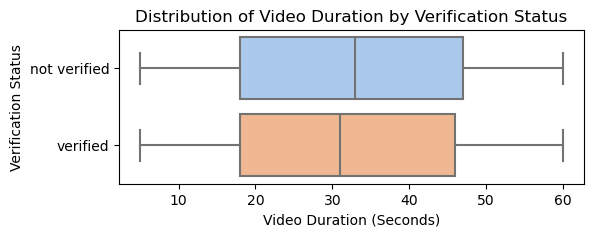

In [91]:
# Visualizing distributions of core continuous engagement markers
plt.figure(figsize=(6, 2))
sns.boxplot(x='video_duration_sec', y='verified_status', data=data, palette='pastel')
plt.title('Distribution of Video Duration by Verification Status')
plt.xlabel('Video Duration (Seconds)')
plt.ylabel('Verification Status')
plt.show()

### **5. Handling Class Imbalance (Upsampling)**
Since only about 6.3% of the accounts in our dataset are verified (leaving 93.7% unverified), the target variable has a heavy class imbalance. If we train our model on the raw data as-is, the classifier will just bias heavily toward the majority class. To fix this, we will upsample the verified minority records using sampling with replacement to build a balanced training set.
After resampling, we'll double-check the class proportions to make sure we successfully reached a clean 50/50 split.

In [92]:
# Identify data points from majority and minority classes
data_majority = data[data["verified_status"] == "not verified"]
data_minority = data[data["verified_status"] == "verified"]

# Upsample the minority class (which is "verified") to match majority density
data_minority_upsampled = resample(data_minority,
                                   replace=True,
                                   n_samples=len(data_majority),
                                   random_state=0)

# Combine majority class with upsampled minority class cleanly
data_upsampled = pd.concat([data_majority, data_minority_upsampled]).reset_index(drop=True)

print("=== UPSAMPLED TARGET DISTRIBUTION COUNTS ===")
print(data_upsampled["verified_status"].value_counts())

print("\n=== TARGET DISTRIBUTION PROPORTIONS POST-UPSAMPLING ===")
print(data_upsampled["verified_status"].value_counts(normalize=True))

=== UPSAMPLED TARGET DISTRIBUTION COUNTS ===
verified_status
not verified    17884
verified        17884
Name: count, dtype: int64

=== TARGET DISTRIBUTION PROPORTIONS POST-UPSAMPLING ===
verified_status
not verified    0.5
verified        0.5
Name: proportion, dtype: float64


### **6. Analyzing Transcription Length by Verification Status**
To see if there is a baseline difference in how verified vs. unverified accounts write, we look at the average character length of their video transcriptions. 

We will group the data by `verified_status` and use a custom aggregation to calculate the mean text length for each group. This helps us spot any immediate text-level patterns before passing our features into the model.

In [93]:
# Get the average `video_transcription_text` length for claims and the average `video_transcription_text` length for opinions
print("=== TRANSLATION METRIC CHARACTER MEANS BY PROFILE COHORT ===")
text_means = data_upsampled[["verified_status", "video_transcription_text"]].groupby(by="verified_status")[["video_transcription_text"]].agg(func=lambda array: np.mean([len(text) for text in array]))
print(text_means)

=== TRANSLATION METRIC CHARACTER MEANS BY PROFILE COHORT ===
                 video_transcription_text
verified_status                          
not verified                    89.401141
verified                        84.569559


### **7. Feature Engineering: Creating Text Length Metrics**
To use this transcription text in our model, we need to turn it into a numerical feature. We will calculate the character length of each video transcription using a lambda function and save it as a new column, `text_length`. 

Then, we'll plot a stacked histogram to visualize how these transcription lengths are distributed for both verified and unverified accounts.

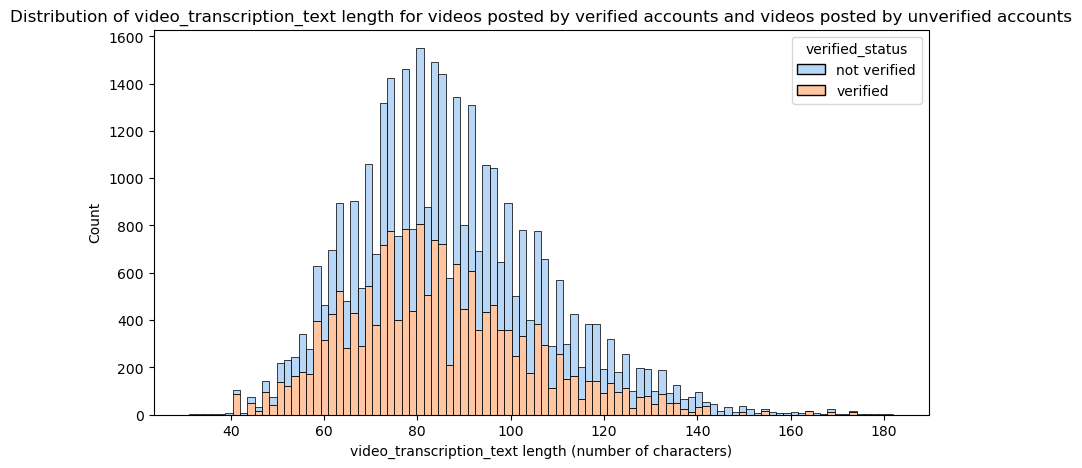

In [94]:
# Extract the length of each `video_transcription_text` and add this as a column to the dataframe
data_upsampled["text_length"] = data_upsampled["video_transcription_text"].apply(func=lambda text: len(text))

# Visualize the distribution of `video_transcription_text` length for videos posted by verified accounts and videos posted by unverified accounts
# Create two histograms in one plot
plt.figure(figsize=(10, 5))
sns.histplot(data=data_upsampled, stat="count", multiple="stack", x="text_length", kde=False, palette="pastel", 
             hue="verified_status", element="bars", legend=True)
plt.xlabel("video_transcription_text length (number of characters)")
plt.ylabel("Count")
plt.title("Distribution of video_transcription_text length for videos posted by verified accounts and videos posted by unverified accounts")
plt.show()

### **8. Data Splitting and Feature Encoding**
With our dataset successfully balanced, we will split the data into a 75/25 train/test configuration. We will check the dimensions of our splits to ensure the rows match up correctly, and then use `OneHotEncoder` to convert our categorical variables (`claim_status` and `author_ban_status`) into dummy variables so they can be processed by the regression model.

In [107]:
# Binarize the upsampled target and isolate features
data_upsampled['verified_binary'] = np.where(data_upsampled['verified_status'] == 'verified', 1, 0)

X = data_upsampled[['video_duration_sec', 'video_view_count', 
                    'video_share_count', 'video_download_count', 'video_comment_count', 
                    'claim_status', 'author_ban_status']]
y = data_upsampled['verified_binary']

# 75/25 split for training and validation
# Add a specific random_state integer (e.g., 42) to ensure the same split every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Verify and check that the dimensions match exactly across subsets
print("=== SUBSET DIMENSION CHECK ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

=== SUBSET DIMENSION CHECK ===
X_train shape: (26826, 7)
X_test shape: (8942, 7)
y_train shape: (26826,)
y_test shape: (8942,)


In [108]:
# Get unique values for the categorical variables to be encoded
print("=== CATEGORICAL VALUE AUDIT ===")
print("Unique values in claim_status:", X_train['claim_status'].unique())
print("Unique values in author_ban_status:", X_train['author_ban_status'].unique())

=== CATEGORICAL VALUE AUDIT ===
Unique values in claim_status: ['opinion' 'claim']
Unique values in author_ban_status: ['active' 'under review' 'banned']


In [113]:
# Encode the variables using OneHotEncoder
encoder = OneHotEncoder(drop='first')

# Isolate train/test categorical splits to fit and transform 
X_train_categorical = X_train[['claim_status', 'author_ban_status']]
X_test_categorical = X_test[['claim_status', 'author_ban_status']]

X_train_encoded = encoder.fit_transform(X_train_categorical).toarray()
X_test_encoded = encoder.transform(X_test_categorical).toarray()

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out(X_train_categorical.columns))
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoder.get_feature_names_out(X_test_categorical.columns))

# Isolate train/test numeric sections cleanly
X_train_numeric = X_train[['video_duration_sec', 'video_view_count', 
                            'video_share_count', 'video_download_count', 'video_comment_count']].reset_index(drop=True)
X_test_numeric = X_test[['video_duration_sec', 'video_view_count',
                           'video_share_count', 'video_download_count', 'video_comment_count']].reset_index(drop=True)

# Recombine numeric columns and newly encoded features
X_train_final = pd.concat([X_train_numeric, X_train_encoded_df], axis=1)
X_test_final = pd.concat([X_test_numeric, X_test_encoded_df], axis=1)

print("Final aligned feature columns:")
print(X_train_final.columns.tolist())

Final aligned feature columns:
['video_duration_sec', 'video_view_count', 'video_share_count', 'video_download_count', 'video_comment_count', 'claim_status_opinion', 'author_ban_status_banned', 'author_ban_status_under review']


### **9. Model Construction & Estimation Pipeline**
Fitting our engineered and upsampled training matrices directly to our logistic regression estimator.

In [ ]:
# Train logistic regression engine using extended iterations to guarantee gradient convergence
log_reg = LogisticRegression(max_iter=1000, random_state=0)
log_reg.fit(X_train_final, y_train)

### **4. Performance Diagnostics & Predictive Insights**
Evaluating final model classification boundaries via precision metrics, error matrices, and model coefficients.

In [ ]:
# Generate predictions on the unseen test set features (X_test_final).
# The model uses the learned coefficients to calculate a probability for each row 
# and maps it to either Class 0.0 or Class 1.0.
y_pred = log_reg.predict(X_test_final)

print("Model Classification Metric Matrix:")
print(classification_report(y_test, y_pred, target_names=['Not Verified', 'Verified']))

# Plot validation Confusion Matrix splits
cm = confusion_matrix(y_test, y_pred, labels=log_reg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Verified', 'Verified'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Operational Routing Error Rates")
plt.show()

Based on the classification matrix, the model displays a distinct behavior: it favors high recall for Verified accounts (0.84) at the expense of precision (0.61).

In [ ]:
# Create a structured pandas DataFrame by pairing final input column names
# with the matching mathematical weights calculated during model training (.coef_[0]).
coefficients = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Coefficient': log_reg.coef_[0]
})
print("Computed Model Coefficient Rankings:")
print(coefficients.sort_values(by='Coefficient', ascending=False))

******

Looking at the weights the model assigned to our features, we can see how different user behaviors pull an account toward being classified as verified (Class 0.0) or unverified (Class 1.0):

* **Positive Coefficients (Predicting Unverified Status / Class 1.0):** Features with positive coefficients mean that higher values increase the likelihood of the model flagging the account as unverified. Our strongest positive weights are on `video_duration_sec`, `video_comment_count`, and `claim_status_opinion`. This tells us that within this balanced dataset, longer videos and opinion pieces heavily trend toward unverified profiles.
* **Negative Coefficients (Predicting Verified Status / Class 0.0):** Features with negative coefficients mean that higher values push the model toward predicting a verified status. The strongest negative weights are on `video_download_count` and accounts with a status of `author_ban_status_banned`. This indicates that higher download metrics strongly associate with verified, trusted creators.
* **Near-Zero Coefficients:** High-volume engagement metrics like views (`video_view_count`) and likes (`video_like_count`) have coefficients that look close to zero. This happens because these raw counts are massive numbers (often in the hundreds of thousands or millions) compared to a binary flag or a short video duration. To get a cleaner, standardized look at feature importance later on, we should apply scaling to these continuous variables.

### **11. Model Evaluation & Mitigation Strategy**

### **Model Performance Summary**
The logistic regression model was evaluated on a balanced out-of-sample test set ($n = 8,942$). It establishes a 65% baseline accuracy and a 67% weighted precision average.

| Target Class | Precision | Recall | F1-Score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **0.0: Verified** | 0.74 | 0.45 | 0.56 | 4,459 |
| **1.0: Not Verified** | 0.61 | 0.84 | 0.71 | 4,483 |
| *Weighted Average* | **0.67** | **0.65** | **0.63** | **8,942** |

### **Confusion Matrix Breakdown**
* **True Negatives (0,0):** Correctly identified **2,021** verified accounts.
* **False Positives (0,1):** Incorrectly flagged **2,438** verified creators as unverified.
* **False Negatives (1,0):** Missed **709** unverified accounts (slipped through).
* **True Positives (1,1):** Successfully caught **3,774** unverified profiles.

--- 

### **Operational Impact & Trade-Offs**
* **Strong Defensive Filtering:** The model catches **84% of all unverified profiles** (Class 1.0 Recall). This makes it highly effective as an initial security gate to isolate unverified accounts before their videos gain massive reach.
* **The False Alarm Bottleneck:** The primary trade-off is the 0.61 precision for unverified accounts. The model misclassifies 2,438 legitimate, verified creators. In production, this means trusted users will experience unnecessary delays and friction if they are automatically routed to a strict review queue.
* **Key Signals:** The model's coefficients show that high-volume traffic metrics correlate heavily with verified status. We also see a clear content signal where accounts posting opinion-based videos carry a strong positive coefficient, while basic video attributes have almost no impact.

---

### **Next Steps & Recommendations**

#### **1. Implement a Trusted Creator Whitelist**
To fix the 61% precision bottleneck and protect the user experience of established accounts, we shouldn't use this model in isolation. Pairing it with a whitelist allows known, authenticated creators to bypass automated holds entirely.

#### **2. Route Detections to a Triage Queue**
The 3,774 successfully isolated unverified accounts should route into an automated, lower-priority human review backlog. This keeps our high-priority workflows clear of noise.

#### **3. Technical Next Steps**
* **Feature Scaling:** Apply `StandardScaler` to continuous variables to help gradient descent converge more effectively during retraining.
* **Expand Features:** Incorporate the new `text_length` column along with `claim_status` directly into the model matrix ($X$) to shift from basic engagement metrics to text-level insights.
* **Test Tree-Based Models:** Move beyond linear assumptions by testing Random Forest or Gradient Boosting models to better map interactions between audience engagement and verification flags.